# Unemployment and Violent Crime Across U.S. States in 2024
### A state-level analysis using merged BLS and FBI data

## Introduction

This project examines whether there is a relationship between unemployment rates and violent crime rates across U.S. states in 2024. To answer this question, I combined two datasets from different official sources: unemployment data from the U.S. Bureau of Labor Statistics (BLS) and violent crime data from the FBI Crime Data Explorer.

The purpose of this project is to use data merging, exploratory analysis, and statistical methods to study whether states with higher unemployment rates also tend to have higher violent crime rates. This project focuses on association, not causation, because the data represents one year of state-level observations rather than a controlled experiment.

## Research Question and Goals

### Research Question
Is there a relationship between state unemployment rates and violent crime rates in the United States in 2024?

### Goals
- Merge two datasets from different sources using state and year
- Describe the unemployment and violent crime variables in the merged data
- Visualize the relationship between unemployment rate and violent crime rate
- Use at least one statistical method to measure the relationship
- Interpret the results clearly and professionally

## Datasets and Sources

This project uses two datasets:

1. **BLS State Unemployment Data (2024)**
   - Source: U.S. Bureau of Labor Statistics
   - Unit of observation: U.S. state
   - Main variable used: unemployment rate

2. **FBI Violent Crime Data (2024)**
   - Source: FBI Crime Data Explorer
   - Unit of observation: U.S. state
   - Main variable used: violent crime rate per 100,000 people

These two datasets were merged by state and year to create one final dataset for analysis.

## Load the Original Datasets

This section loads the two original datasets that will be used in the project. One dataset contains unemployment information by state from the U.S. Bureau of Labor Statistics, and the other contains violent crime information by state from the FBI Crime Data Explorer.

I load both files first so I can inspect their structure before cleaning and merging them.

In [5]:
import pandas as pd

bls = pd.read_csv("bls_data.csv")
crime = pd.read_csv("CIUS_Crime_in_the_United_States_byState_2024.csv")

bls

,FIPS Code,State,Year,Civilian non-institutional population,Total,Percent of population,Total_Employment,Percent of population.1,Total_Unemployment,Rate
0,1,Alabama,2024,"4,096,918","2,359,390",57.6,"2,289,120",55.9,"70,270",3.0
1,2,Alaska,2024,"553,822","360,367",65.1,"344,005",62.1,"16,362",4.5
2,4,Arizona,2024,"6,041,127","3,741,665",61.9,"3,602,956",59.6,"138,709",3.7
3,5,Arkansas,2024,"2,426,129","1,411,833",58.2,"1,362,381",56.2,"49,452",3.5
4,6,California,2024,"31,646,522","19,692,824",62.2,"18,650,672",58.9,"1,042,152",5.3
5,8,Colorado,2024,"4,815,264","3,265,465",67.8,"3,130,455",65.0,"135,010",4.1
6,9,Connecticut,2024,"3,001,078","1,932,754",64.4,"1,868,860",62.3,"63,894",3.3
7,10,Delaware,2024,"851,021","510,899",60.0,"490,887",57.7,"20,012",3.9
8,12,Florida,2024,"19,014,602","11,114,233",58.5,"10,741,571",56.5,"372,662",3.4
9,13,Georgia,2024,"8,799,428","5,423,268",61.6,"5,237,835",59.5,"185,433",3.4


In [6]:
crime

,state,year,population,violent_crime_total,violent_crime_rate
0,Connecticut,2024,"3,675,069","4,998",136.0
1,Maine,2024,"1,405,012","1,406",100.1
2,Massachusetts,2024,"7,136,171","22,457",314.7
3,New Hampshire,2024,"1,409,032","1,551",110.1
4,Rhode Island,2024,"1,112,308","1,708",153.6
5,Vermont,2024,"648,493","1,421",219.1
6,New Jersey,2024,"9,500,851","20,684",217.7
7,New York,2024,"19,867,248","75,528",380.2
8,Pennsylvania,2024,"13,078,751","32,123",245.6
9,Illinois,2024,"12,710,158","36,756",289.2


Both datasets loaded successfully. The unemployment dataset has original column names from the source file, while the crime dataset is already in a cleaner format. The next step is to clean and standardize the columns so the two datasets can be merged correctly.

## Clean the BLS Dataset

Before cleaning, the unemployment dataset has long column names and numeric values that may need to be converted into proper numeric format. I rename the columns, trim the state names, and convert the relevant columns to numeric values so the dataset is easier to analyze.

In [9]:
bls = bls.rename(columns={
    "FIPS Code": "fips_code",
    "State": "state",
    "Year": "year",
    "Civilian non-institutional population": "civilian_noninstitutional_population",
    "Total": "civilian_labor_force_total",
    "Percent of population": "civilian_labor_force_pct",
    "Total_Employment": "total_employment",
    "Percent of population.1": "employment_pct",
    "Total_Unemployment": "total_unemployment",
    "Rate": "unemployment_rate"
})

bls["state"] = bls["state"].str.strip()

bls_numeric_cols = [
    "fips_code",
    "year",
    "civilian_noninstitutional_population",
    "civilian_labor_force_total",
    "civilian_labor_force_pct",
    "total_employment",
    "employment_pct",
    "total_unemployment",
    "unemployment_rate"
]

for col in bls_numeric_cols:
    bls[col] = pd.to_numeric(
        bls[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

bls

,fips_code,state,year,civilian_noninstitutional_population,civilian_labor_force_total,civilian_labor_force_pct,total_employment,employment_pct,total_unemployment,unemployment_rate
0,1,Alabama,2024,4096918,2359390,57.6,2289120,55.9,70270,3.0
1,2,Alaska,2024,553822,360367,65.1,344005,62.1,16362,4.5
2,4,Arizona,2024,6041127,3741665,61.9,3602956,59.6,138709,3.7
3,5,Arkansas,2024,2426129,1411833,58.2,1362381,56.2,49452,3.5
4,6,California,2024,31646522,19692824,62.2,18650672,58.9,1042152,5.3
5,8,Colorado,2024,4815264,3265465,67.8,3130455,65.0,135010,4.1
6,9,Connecticut,2024,3001078,1932754,64.4,1868860,62.3,63894,3.3
7,10,Delaware,2024,851021,510899,60.0,490887,57.7,20012,3.9
8,12,Florida,2024,19014602,11114233,58.5,10741571,56.5,372662,3.4
9,13,Georgia,2024,8799428,5423268,61.6,5237835,59.5,185433,3.4


After cleaning, the BLS dataset has clearer column names and numeric values ready for analysis. The next step is to clean the FBI crime dataset in the same way.

## Clean the FBI Dataset

Before cleaning, the FBI dataset is already in a simpler format, but I still standardize the state names and convert the numeric fields into numeric values so it can be merged correctly with the BLS data.

In [10]:
crime["state"] = crime["state"].str.strip()

crime_numeric_cols = [
    "year",
    "population",
    "violent_crime_total",
    "violent_crime_rate"
]

for col in crime_numeric_cols:
    crime[col] = pd.to_numeric(
        crime[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

crime

,state,year,population,violent_crime_total,violent_crime_rate
0,Connecticut,2024,3675069,4998,136.0
1,Maine,2024,1405012,1406,100.1
2,Massachusetts,2024,7136171,22457,314.7
3,New Hampshire,2024,1409032,1551,110.1
4,Rhode Island,2024,1112308,1708,153.6
5,Vermont,2024,648493,1421,219.1
6,New Jersey,2024,9500851,20684,217.7
7,New York,2024,19867248,75528,380.2
8,Pennsylvania,2024,13078751,32123,245.6
9,Illinois,2024,12710158,36756,289.2


After cleaning, the FBI dataset is also ready to merge.

## Prepare the Merge

Before merging, I check the year values in both datasets. Since both datasets only contain data from 2024, the observational unit is state rather than state-year. Because of that, I only need to merge on `state`.

In [11]:
bls["year"].value_counts(dropna=False)

year
2024    50
Name: count, dtype: int64

In [12]:
crime["year"].value_counts(dropna=False)

year
2024    50
Name: count, dtype: int64

Since both datasets only contain observations from 2024, I will merge them on `state` only. To avoid having two year columns in the merged result, I will drop the `year` column from the crime dataset before merging.

In [13]:
crime_for_merge = crime.drop(columns=["year"]).copy()

crime_for_merge

,state,population,violent_crime_total,violent_crime_rate
0,Connecticut,3675069,4998,136.0
1,Maine,1405012,1406,100.1
2,Massachusetts,7136171,22457,314.7
3,New Hampshire,1409032,1551,110.1
4,Rhode Island,1112308,1708,153.6
5,Vermont,648493,1421,219.1
6,New Jersey,9500851,20684,217.7
7,New York,19867248,75528,380.2
8,Pennsylvania,13078751,32123,245.6
9,Illinois,12710158,36756,289.2


The year column for crime dataset was successfully removed. 

## Merge the Datasets

Now that both datasets are cleaned and use the same state names, I merge them with an inner join on `state`. I also use `validate="1:1"` to confirm that each state appears only once in each dataset.

In [14]:
merged_df = pd.merge(
    bls,
    crime_for_merge,
    on="state",
    how="inner",
    validate="1:1"
)

merged_df

,fips_code,state,year,civilian_noninstitutional_population,civilian_labor_force_total,civilian_labor_force_pct,total_employment,employment_pct,total_unemployment,unemployment_rate,population,violent_crime_total,violent_crime_rate
0,1,Alabama,2024,4096918,2359390,57.6,2289120,55.9,70270,3.0,5157699,18561,359.9
1,2,Alaska,2024,553822,360367,65.1,344005,62.1,16362,4.5,740133,5359,724.1
2,4,Arizona,2024,6041127,3741665,61.9,3602956,59.6,138709,3.7,7582384,31991,421.9
3,5,Arkansas,2024,2426129,1411833,58.2,1362381,56.2,49452,3.5,3088354,17893,579.4
4,6,California,2024,31646522,19692824,62.2,18650672,58.9,1042152,5.3,39431263,191641,486.0
5,8,Colorado,2024,4815264,3265465,67.8,3130455,65.0,135010,4.1,5957493,28378,476.3
6,9,Connecticut,2024,3001078,1932754,64.4,1868860,62.3,63894,3.3,3675069,4998,136.0
7,10,Delaware,2024,851021,510899,60.0,490887,57.7,20012,3.9,1051917,3795,360.8
8,12,Florida,2024,19014602,11114233,58.5,10741571,56.5,372662,3.4,23372215,62423,267.1
9,13,Georgia,2024,8799428,5423268,61.6,5237835,59.5,185433,3.4,11180878,36420,325.7


After the merge, each row represents one U.S. state in 2024 and includes both unemployment and violent crime variables in the same row.

## Verify the Merge

To verify that the merge worked correctly, I check the size of the merged dataset, look for duplicate states, and check whether any state names appear in one dataset but not the other.

In [15]:
merged_df.shape

(50, 13)

If the merge worked correctly, the merged dataset should have 50 rows, one for each U.S. state.

In [16]:
merged_df["state"].duplicated().sum()

np.int64(0)

This checks whether any state appears more than once in the merged dataset. I expect the result to be 0.

In [17]:
set(bls["state"]) - set(crime["state"])

set()

In [18]:
set(crime["state"]) - set(bls["state"])

set()

These two checks show whether any state names appear in one dataset but not the other. If both results are empty sets, then the state names matched correctly across both datasets.

In [19]:
merged_df[["state", "year", "unemployment_rate", "violent_crime_rate"]]

,state,year,unemployment_rate,violent_crime_rate
0,Alabama,2024,3.0,359.9
1,Alaska,2024,4.5,724.1
2,Arizona,2024,3.7,421.9
3,Arkansas,2024,3.5,579.4
4,California,2024,5.3,486.0
5,Colorado,2024,4.1,476.3
6,Connecticut,2024,3.3,136.0
7,Delaware,2024,3.9,360.8
8,Florida,2024,3.4,267.1
9,Georgia,2024,3.4,325.7


This final check lets me visually confirm that each row now contains both unemployment data and violent crime data for the same state.

## Export the Merged Dataset

After verifying that the merge worked correctly, I export the final merged dataset as a CSV file. This gives me a clean file that I can reuse later in the project and also include in the final published materials.

In [20]:
merged_df.to_csv("merged_unemployment_crime_2024.csv", index=False)

"merged_unemployment_crime_2024.csv exported successfully."

'merged_unemployment_crime_2024.csv exported successfully.'

After exporting the merged dataset, I can move on to exploratory analysis. The goal of the next section is to understand the main variables and look for patterns before applying a statistical method.

## Exploratory Data Analysis

Before applying a statistical method, I first explore the merged dataset. This helps me understand the distribution of the variables and see whether there appears to be a relationship between unemployment rate and violent crime rate across states.

### Summary Statistics

Before creating graphs, I begin by looking at summary statistics for the main variables in the project. This gives a quick overview of the typical values, spread, and overall range of unemployment and violent crime across states.

In [21]:
merged_df[["unemployment_rate", "violent_crime_rate", "population"]].describe()

,unemployment_rate,violent_crime_rate,population
count,50.000000,50.000000,5.000000e+01
mean,3.668000,337.062000,6.788175e+06
std,0.774713,139.649913,7.630883e+06
min,1.800000,100.100000,5.876180e+05
25%,3.125000,229.850000,2.002580e+06
50%,3.650000,320.200000,4.593056e+06
75%,4.175000,422.575000,7.864231e+06
max,5.400000,724.100000,3.943126e+07


After viewing the summary statistics, I can better understand the scale of the variables. In particular, the unemployment rate and violent crime rate are measured on very different numeric scales, so graphs will help make the relationship easier to interpret.

### Look at the Main Variables

Before studying the relationship between the two variables, I want to inspect the main columns that will be used in the analysis.

In [22]:
merged_df[["state", "unemployment_rate", "violent_crime_rate", "population"]]

,state,unemployment_rate,violent_crime_rate,population
0,Alabama,3.0,359.9,5157699
1,Alaska,4.5,724.1,740133
2,Arizona,3.7,421.9,7582384
3,Arkansas,3.5,579.4,3088354
4,California,5.3,486.0,39431263
5,Colorado,4.1,476.3,5957493
6,Connecticut,3.3,136.0,3675069
7,Delaware,3.9,360.8,1051917
8,Florida,3.4,267.1,23372215
9,Georgia,3.4,325.7,11180878


After viewing the key variables, I can confirm that each state has both an unemployment rate and a violent crime rate, which are the two main variables needed to answer the research question.

### Scatter Plot

Before calculating a statistical measure, I create a scatter plot of unemployment rate and violent crime rate. A scatter plot is useful because it shows the overall pattern of the relationship and whether the points seem to move upward, downward, or show little pattern.

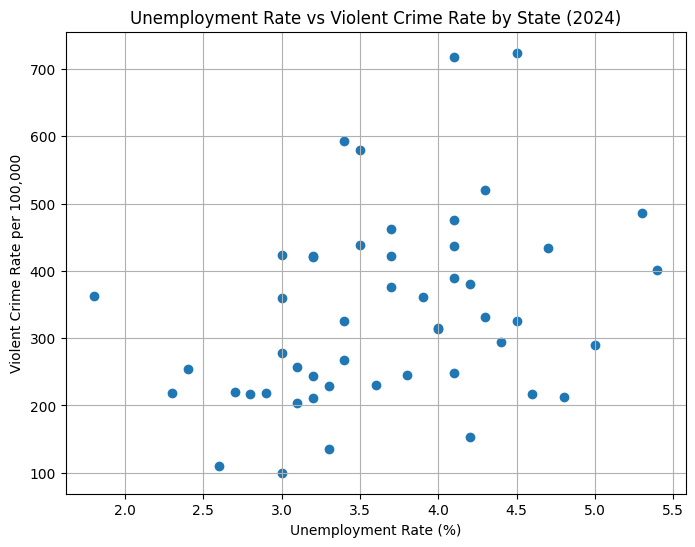

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(merged_df["unemployment_rate"], merged_df["violent_crime_rate"])
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Violent Crime Rate per 100,000")
plt.title("Unemployment Rate vs Violent Crime Rate by State (2024)")
plt.grid(True)
plt.show()

After viewing the scatter plot, I can make an initial visual judgment about whether states with higher unemployment rates also tend to have higher violent crime rates. The graph does not prove causation, but it helps show whether a possible relationship is present.

### Correlation

Before moving to a more formal statistical method, I calculate the correlation between unemployment rate and violent crime rate. Correlation helps measure the strength and direction of the linear relationship between the two variables.

In [24]:
merged_df[["unemployment_rate", "violent_crime_rate"]].corr()

,unemployment_rate,violent_crime_rate
unemployment_rate,1.000000,0.330572
violent_crime_rate,0.330572,1.000000


After calculating the correlation, I found a correlation of about **0.33** between unemployment rate and violent crime rate. This suggests a **positive but moderate relationship**: states with higher unemployment rates tend to also have higher violent crime rates, but the relationship is not very strong. The scatter plot supports this result, since the points show a slight upward trend but are still fairly spread out.

## Statistical Analysis

After exploring the data visually and with a correlation matrix, I now apply a formal statistical method. Since the goal is to study the relationship between unemployment rate and violent crime rate, I use a simple linear regression with violent crime rate as the response variable and unemployment rate as the explanatory variable.

### Set Up the Regression

Before running the regression, I define the explanatory variable and the response variable. In this project, unemployment rate is the explanatory variable because I want to examine whether differences in unemployment are associated with differences in violent crime rates across states.

In [25]:
x = merged_df["unemployment_rate"]
y = merged_df["violent_crime_rate"]

x, y

(0     3.0
 1     4.5
 2     3.7
 3     3.5
 4     5.3
 5     4.1
 6     3.3
 7     3.9
 8     3.4
 9     3.4
 10    2.8
 11    3.6
 12    5.0
 13    4.0
 14    3.2
 15    3.5
 16    4.8
 17    4.3
 18    3.0
 19    3.2
 20    4.0
 21    4.7
 22    3.1
 23    3.2
 24    3.7
 25    3.0
 26    2.7
 27    5.4
 28    2.6
 29    4.6
 30    4.1
 31    4.2
 32    3.7
 33    2.4
 34    4.4
 35    3.2
 36    4.3
 37    3.8
 38    4.2
 39    4.1
 40    1.8
 41    3.4
 42    4.1
 43    3.3
 44    2.3
 45    2.9
 46    4.5
 47    4.1
 48    3.0
 49    3.1
 Name: unemployment_rate, dtype: float64,
 0     359.9
 1     724.1
 2     421.9
 3     579.4
 4     486.0
 5     476.3
 6     136.0
 7     360.8
 8     267.1
 9     325.7
 10    217.7
 11    230.6
 12    289.2
 13    312.9
 14    243.3
 15    438.7
 16    213.1
 17    519.8
 18    100.1
 19    420.4
 20    314.7
 21    434.3
 22    256.6
 23    210.5
 24    462.0
 25    423.5
 26    220.5
 27    402.0
 28    110.1
 29    217.7
 30    717.1
 31  

After defining the variables, I am ready to run the regression model. This will estimate the direction and strength of the relationship between unemployment rate and violent crime rate.

### Run the Simple Linear Regression

Before interpreting the relationship, I run a simple linear regression model. This model estimates how much violent crime rate changes, on average, when unemployment rate increases by one percentage point.

In [28]:
from scipy.stats import linregress

regression_result = linregress(x, y)

regression_result

LinregressResult(slope=np.float64(59.588939365088), intercept=np.float64(118.48977040885725), rvalue=np.float64(0.330571643137617), pvalue=np.float64(0.019041724191865627), stderr=np.float64(24.55560419854912), intercept_stderr=np.float64(92.01768319272992))

After running the regression, I now have the key output values needed for interpretation. To make them easier to read, I will organize them in a small summary table.

### Regression Results Table

Before drawing any conclusions, I summarize the main regression results in a clear table. The most important values are the slope, the p-value, and the R-squared value.

In [29]:
regression_summary = pd.DataFrame({
    "Statistic": ["Slope", "Intercept", "R-value", "R-squared", "P-value", "Standard error"],
    "Value": [
        regression_result.slope,
        regression_result.intercept,
        regression_result.rvalue,
        regression_result.rvalue**2,
        regression_result.pvalue,
        regression_result.stderr
    ]
})

regression_summary

,Statistic,Value
0,Slope,59.588939
1,Intercept,118.489770
2,R-value,0.330572
3,R-squared,0.109278
4,P-value,0.019042
5,Standard error,24.555604


After creating the summary table, I can clearly see the main statistical results of the model. These values will help answer whether the relationship is positive or negative, how strong it is, and whether it is statistically significant.

### Add the Regression Line to the Scatter Plot

Before interpreting the model, I add the fitted regression line to the scatter plot. This helps show visually how the regression line summarizes the overall pattern in the data.

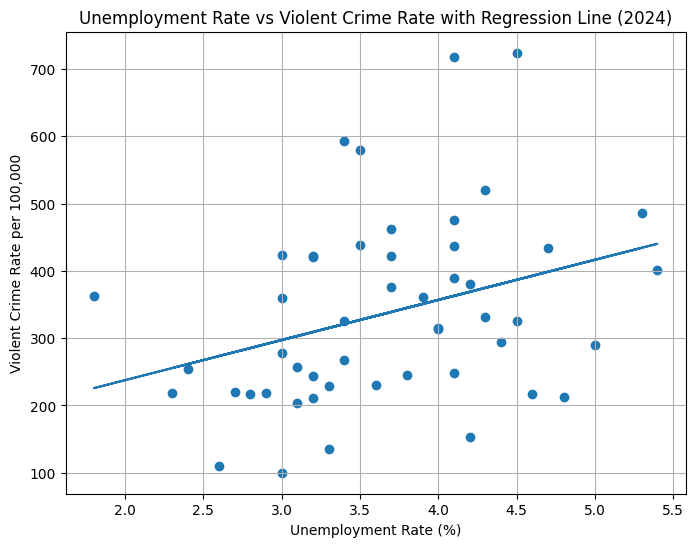

In [30]:
import matplotlib.pyplot as plt

y_pred = regression_result.intercept + regression_result.slope * x

plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Violent Crime Rate per 100,000")
plt.title("Unemployment Rate vs Violent Crime Rate with Regression Line (2024)")
plt.grid(True)
plt.show()

After adding the regression line, I can compare the fitted trend to the actual data points. This visual will help support the final interpretation of the regression results.

After running the simple linear regression, the results show a **positive relationship** between unemployment rate and violent crime rate across U.S. states in 2024. The slope is about **59.59**, which means that for each 1 percentage point increase in unemployment rate, the model predicts an increase of about **59.6 violent crimes per 100,000 people**, on average.

The **p-value is 0.019**, which is below 0.05, so the relationship is statistically significant at the 5% level. This suggests that the positive relationship is unlikely to be due to random chance alone. On to of that, after interpreting the slope and p-value, I also consider the strength of the model. The **R-squared value is about 0.109**, which means that unemployment rate explains about **10.9%** of the variation in violent crime rate across states.

This means the model finds a real relationship, but it is still a **fairly weak one**. Unemployment rate helps explain some of the differences in violent crime rates, but most of the variation is likely explained by other factors not included in this model.

## Conclusion

After completing the exploratory analysis and simple linear regression, I conclude that there is a **positive relationship** between unemployment rate and violent crime rate across U.S. states in 2024. States with higher unemployment rates tended to also have higher violent crime rates.

However, the relationship is only **moderate to weak**, and the regression explains a limited share of the variation in violent crime rates. For that reason, unemployment rate should not be viewed as the only or main explanation for differences in violent crime across states.

Overall, this project shows that unemployment and violent crime were related in 2024, but the results should be interpreted as an **association rather than causation**.